Since one can't install ipykernel in .venv, you need to install the folder as a package on ```(virtual-env)```
On DAP:
* upload the `graph-ensembles.zip` directly in `corealgos`;
* open jupyter notebook and the terminal (`cmd + j` ?);
* move it to the personal workind directory `aws s3 mv s3://corealgos/graph-ensembles.zip ./graph-ensembles.zip`
* do `unzip graph-ensembles.zip` or we can try directly `unzip -o graph-ensemble.zip ./graph-ensemble`;
* `source deactivate` (the `virtual-env`) and the standard jupter kernel is selected;
* install via `pip install --editable . --config-settings editable_mode=compat`
* create a cell down here and do `import graph_ensembles` to check the installation;

Commands
* For this proj, ```vars``` and ```plots``` are saved in `./outputs`, but in the old version in
```/home/inghero/data/corealgos/rmilocco/outputs/datasets/ING-Directed```
* Delete folders on dap: ```mc rm --force --purge folder```
* To save new plots, delete previous ones with
```mc rm --force --purge dap/corealgos/rmilocco/outputs/datasets/ING-Directed```

On local:
* macOS: Zip outside the ``graph-ensembles`` folder: 
<br>```zip -rX graph-ensembles.zip graph-ensembles -x "graph-ensembles/src/graph_ensembles.egg-info/*" ".*" "*/.*" "*/__pycache__/*"```

In [1]:
# import image module
from IPython.display import Image

# get the image
Image(url="../im1.png", width = 500)

Claim: by reconstructing the unobserved, we may close the gap between the total Page-Rank and Page-Rank only inside the ING-clients

1) Split the nodes into ING (`vI`) and `ROW` (`vR`);

2) Find ``eI`` as the edges only between ``vI`` + drop the ``vI`` with no links (in case, a `vI` is connected only to ROW-nodes);

3) Accordingly, define the edges as `intra` (`eI`), `inter`, `row`; 

4) Calculate the Page-Rank of only the `intra` nodes and compare it with the full graph PR;
Now, we expect that the 2 PR are different. So,
5) Freeze the `eI` and fit $\delta$ parameter as 
    * $L_I \stackrel{!}{=} \langle L_I \rangle(\delta_I) := \sum_{i \in I, j \in I} p_{ij}(\delta_I) \rightarrow $ the remaining probabilities are `inter, row` $p_{ir} := 1 - \exp(-\delta_{I} s^{out}_i s^{in}_r)$ with which we can sample and obtain the average $ \langle PR \rangle$ over the enhanced-network (`eI` (deterministic) + `e-sampled`);

    * $L_U = L_I + L_{inter} \stackrel{!}{=} L_I + \sum_{i \in I, r \in R} (p_{ir}(\delta_{U}) + p_{ri}(\delta_{U})) \rightarrow $ do the same calculations;

    * $L_{tot} \stackrel{!}{=} \langle L_{tot} \rangle(\delta_I) := L_I + \sum_{i \in I, r \in R} (p_{ir}(\delta_{tot}) + p_{ri}(\delta_{tot})) + \sum_{r \in R, t \in R} (p_{rt} + p_{tr})(\delta_{tot}) \rightarrow $ same;

In [2]:
# auto-reload the packages at every run
%load_ext autoreload
%autoreload 2

#display all the results not only the last one
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

try:
    corpkey = True if os.environ['DSBOX_USERNAME'] else None
    %pip install matplotlib pandas scipy numba fast_pagerank tqdm
except:
    corpkey = None

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from fast_pagerank import pagerank_power
import graph_ensembles as ge
from graph_ensembles import sparse as sp
import graph_ensembles.utils as utils
import graph_ensembles.dependencies as dep

utils.latex_mpl_params(corpkey)

dataset_name = "ING" #"recNET"
dataset_direction = "Directed"
id_code, cg_method, year = "grid_id", "random", 2022

In [3]:
# note that inside the kwargs there is a copy of the pdtrans
pdtrans, kwargs, total_levels = \
    ge.dataset_loader(dataset_name, dataset_direction = dataset_direction,
                    corpkey = corpkey, id_code = id_code, cg_method = cg_method,
                    year = year, max_num_entries = None)


Reading from local source


Find the (real) distribution of naics, using this code

In [4]:
# def _naics_num_firms(df):
#     df.loc[:, "nroffirms"] = 1
#     naics_num_firms = df.groupby(by = "payer_naics_code").sum().loc[:, "nroffirms"].to_dict()
#     return naics_num_firms
# naics_num_firms = _naics_num_firms(pdtrans.copy())
# os.makedirs("./outputs", exist_ok=True)
# utils.save_dict(full_path="./outputs/naics_num_firms.pkl", dict_ = naics_num_firms)

Define all the vertex and edges

In [5]:
e = pdtrans.loc[:, [f'payer_{id_code}', f'beneficiary_{id_code}']]
unique_nodes_from = lambda df: pd.DataFrame(data = np.unique(df.to_numpy().ravel('K')), columns = ["id"])
v = unique_nodes_from(e)
e = pdtrans.iloc[:, ::2] # payer, beneficiary, amount_euro
e.columns = ["src", "dst", "amount"] 

e.head()

,src,dst,amount
0,0,198,481.085507
1,0,1587,1161.494056
2,0,3118,1309.732465
3,0,4909,447.122193
4,0,5006,764.965687


Create the full graph to be used as test

In [6]:
kwargs_graph = {'name' : 'ING', 'level' : 0, 'corpkey' : corpkey}
g = sp.graphs.DiGraph(v, e, **kwargs_graph)
# g.load_or_create_degrees()

# pr_g = pagerank_power(g.adj, p=0.85, max_iter=100,
#                     tol=1e-06, personalize=None, reverse=True)

Create the `gI` and calculate its Page-Rank

In [7]:
# from matplotlib import colormaps as cmaps
# from matplotlib.colors import to_hex
# from tqdm import trange

# intra_size, num_seed = 0.3, 2
# colors = cmaps["viridis"](np.linspace(0,1,num_seed))

# fig, ax = plt.subplots(figsize=(6, 6))
# for seed in trange(num_seed, desc = "Splitting and Computing the PageRank"):
#     # split the verteces and filter the edges btw vI vertices
#     vI, eI = g.split_intra_row(v, e, intra_size = intra_size, seed = seed)

#     kwargs_graph.update({'graph_kind' : "intra",})
#     gI = sp.graphs.DiGraph(vI, eI, **kwargs_graph)

#     pr_gI = pagerank_power(gI.adj, p=0.85, max_iter=100,
#                     tol=1e-06, personalize=None, reverse=True)

#     # pr_g has all the nodes, therefore filter only the vI
#     # id_dict = {node : idx}. The map is gI_nodes --> has keys of id_dict_Full --> returning the idx_Full
#     idx_IntraNode2Full = list(map(lambda x: g.id_dict.get(x), gI.id_dict))
#     pr_g_on_I = pr_g[idx_IntraNode2Full]

#     # plot the PageRanks
#     _ = ax.plot([pr_g_on_I.min(), pr_g_on_I.max()],
#             [pr_g_on_I.min(), pr_g_on_I.max()],
#             'r--')

#     ms, alpha = 30, 0.2
#     _ = ax.scatter(pr_g_on_I, pr_gI, alpha=alpha, label = f"Split {seed}", c = to_hex(colors[seed]), s = ms)
#     _ = ax.set(
#         xlabel='Full-PR on Intra',
#         ylabel='Intra PR',
#         title='PageRank',
#         xscale='log',
#         yscale='log'
#     )
#     leg = ax.legend(fontsize = 10)
#     for lh in leg.legend_handles:
#         lh.set_alpha(1)
#         lh.set_sizes([60])
#     ax.grid(False)

# utils.save_fig(fig, full_path = g.plots_general_dir + f"/PageRanks_on_Intra/PR_{intra_size}_{num_seed}.pdf")
# plt.close()

In [8]:
# g.in_strength()
# g.out_strength()
# gI._in_strength = g._in_strength[idx_IntraNode2Full]
# gI._out_strength = g._out_strength[idx_IntraNode2Full]

Fit `delta` with `L_tot` num edges

In [9]:
# create another dictionary for gI
kwargs_model = kwargs_graph.copy()
kwargs_model.update({"name" : "Invariant"})
model = sp.ScaleInvariantModel(g, **kwargs_model)

In [10]:
x0 = [1.8996372e-17]
model.load_or_fit(x0 = x0[0], maxiter = 10, verbose = 2)

-Load the parameter enforcing num_edges_full


Create a split of ``v`` into `vI`

The `full` sampling procedure stays the same for all the fitting methods of delta (intra, united, full)

In [ ]:
from tqdm import trange

intra_size = 0
num_seed = 10 if intra_size > 0 else 1
num_graph_samples_per_seed = 500
resample_last_graph = False

# dir path to check how many graphs have to be sampled
vars_dir_ensembles = model.vars_dir.replace("vars", "vars/ensembles") + f"/intra_size{intra_size}"

for seed in range(num_seed):

    # check if samples are already completed
    model.vars_dir_ensembles = vars_dir_ensembles
    if intra_size > 0:
        model.vars_dir_ensembles += f"/vert_seed{seed}"

    # find the max graph idx in the model.vars_dir and sample the rest
    max_idx = utils.max_sampled_graph_idx(model.vars_dir_ensembles)

    # if all the graphs are there, then continue to check the next seed
    if max_idx == num_graph_samples_per_seed - 1:
        continue
    
    unsampled_vI, added_edges = None, None

    if intra_size > 0:

        # split the verteces and filter the edges btw vI vertices
        vI, eI = g.split_intra_row(v, e, intra_size = intra_size, seed = seed)

        # convert the id nodes into index 
        # use the g.id_dict since the objective is to sample the full network. So, nodes must have the full-indexes 
        idx_vI = list(map(g.id_dict.get, vI.id.values))

        # set the unsampled nodes, s.t. every pair will be discarded from sampling
        unsampled_vI = np.zeros(model.num_vertices, dtype=np.bool_)
        unsampled_vI[idx_vI] = True

        # added_edges (rmb: _src are contig integers whereas for the v is the index)
        added_edges = eI.loc[:, ["_src", "_dst"]]
    
    print(f'-For splitting # {seed}: {max_idx + 1} graphs already sampled, {np.clip(num_graph_samples_per_seed - max_idx - 1, 0, None)} remaining')
    
    # Note: the seed only works for solo-agent. The graph-sampling is parallelized, so it would be random even if seed specified.
    # That's why .sample() has graph_idx as argument
    # for graph_seed in trange(max_idx, num_graph_samples_per_seed, 
    #                 desc=f"-Total progress {int(np.round(seed/num_seed * 100))}%, Inner Graph Sampling", position = 0, leave= True):
        
    #     gs = model.sample(ref_g = g, unsampled_vI = unsampled_vI, added_edges = added_edges, graph_idx = graph_seed)
    # print()

    break

-For splitting # 0: 462 graphs already sampled, 38 remaining


In [18]:
max_idx

461

In [15]:
import numpy as np

vars_dir_ensembles = model.vars_dir.replace("vars", "vars/ensembles") + f"/intra_size0"
max_idx = utils.max_sampled_graph_idx(vars_dir_ensembles)
num_samples = max_idx + 1
net_meas = "_num_edges"
ensemble_net_meas = np.empty(shape = num_samples)

# store in array all the values
for i in range(num_samples):
    graph_net_meas = utils.load_dict(vars_dir_ensembles + f"/graph{i}/graph{i}.pkl")[net_meas]
    ensemble_net_meas[i] = graph_net_meas

    # num_graphs = i + 1
    # if num_graphs >= 2:
    #     idx_sampled_graphs[num_graphs] = all_combinations(num_samples, num_graphs)

ens_mean = np.mean(ensemble_net_meas)
ensemble_net_meas -= model.num_edges

# ensemble_net_meas is your array of values, shape (num_samples,)
prog_mean = np.empty(num_samples)

for k in range(num_samples):
    vals = ensemble_net_meas[:k+1]
    prog_mean[k] = np.mean(vals)

In [16]:
ens_mean - model.num_edges

np.float64(-57.09956710040569)

[Text(0.5, 0, '# of sampled graphs'),
 Text(0, 0.5, 'Mean'),
 Text(0.5, 1.0, 'Mean of Sampled _num_edges')]

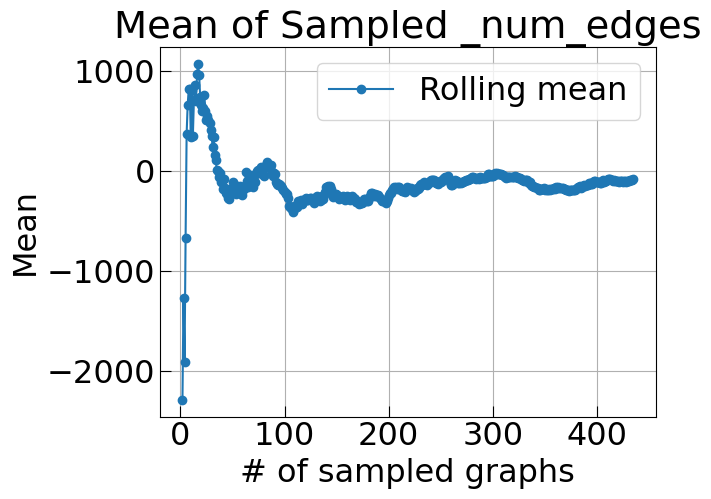

In [17]:
fig, ax = plt.subplots()
x = np.arange(2, len(prog_mean) + 2)
ax.plot(
    x,
    prog_mean,
    '-o',
    label='Rolling mean'
)
ax.set(
    xlabel="# of sampled graphs",
    ylabel="Mean",
    title=f"Mean of Sampled {net_meas}",
    # yscale = "log"
)
ax.grid(True)
ax.legend()
plt.show()

In [ ]:
import numpy as np
import math

vars_dir_ensembles = model.vars_dir.replace("vars", "vars/ensembles") + f"/intra_size0"
max_idx = utils.max_sampled_graph_idx(vars_dir_ensembles)
net_meas = "_num_edges"

prog_mean_std = np.empty((max_idx, 2), dtype=float)

mean = 0.0
M2 = 0.0

for i in range(max_idx):
    graph_net_meas = utils.load_dict(vars_dir_ensembles + f"/graph{i}/graph{i}.pkl")[net_meas]
    n = i + 1
    delta = graph_net_meas - mean
    mean += delta / n
    delta2 = graph_net_meas - mean
    M2 += delta * delta2
    std = math.sqrt(M2 / (n - 1)) if n > 1 else float('nan')
    prog_mean_std[i, 0] = mean
    prog_mean_std[i, 1] = std

<ErrorbarContainer object of 3 artists>

Text(0.5, 0, '# of sampled graphs')

Text(0, 0.5, 'Rolling mean ± std')

Text(0.5, 1.0, 'Rolling Mean and Std of Sampled Graphs')

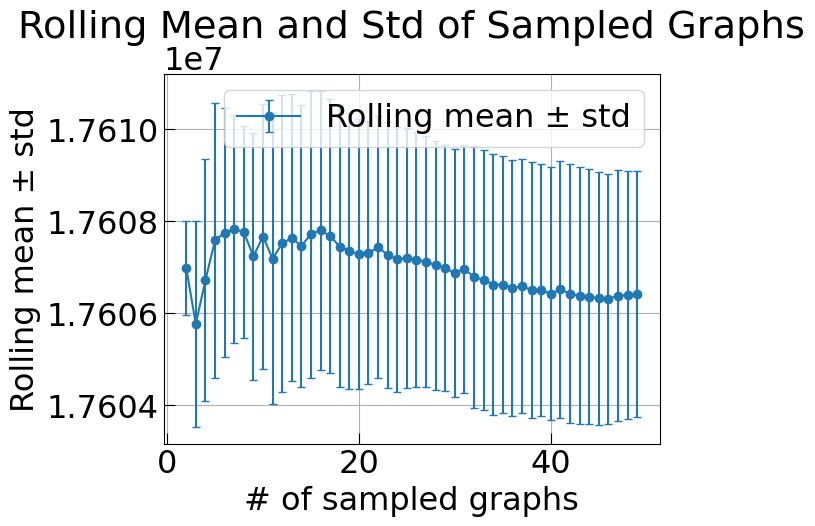

### Miscellanea

Do Page-Rank for `gU`

In [ ]:
# find idx of edges containing v and filter edges
idx_at_least_one_ = lambda vI: e['src'].isin(vI['id']) | e['dst'].isin(vI['id'])

# containing vI, vR
idx_eU = idx_at_least_one_(vI)

# select the edge ING
eU = 3
# eU = edge_idx(idx_eU)

# reselect vU, since using v leads to inactive nodes not well-handled by the DiGraph
vU = unique_nodes_from(eU.iloc[:,:2])

In [ ]:
# kwargs_graph.update({'perc_intra_nodes' : perc_intra_nodes, 'seed' : seed, 'graph_kind' : "intra_inter",})
gU = sp.graphs.DiGraph(vU, eU, **kwargs_graph)
# g.load_or_create_degrees()

Compare the United PageRank vs Full PageRank over all the `vU` 

In [ ]:
pr_gU = pagerank_power(gU.adj, p=0.85, max_iter=100,
                   tol=1e-06, personalize=None, reverse=True)

In [ ]:
idx_IntraNode2United = list(map(lambda x: gU.id_dict.get(x), gI.id_dict))
pr_gU_on_Intra = pr_gU[idx_IntraNode2United]

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([pr_g_on_I.min(), pr_g_on_I.max()],
        [pr_g_on_I.min(), pr_g_on_I.max()],
        'r--')

ms, alpha = 30, 0.6
ax.scatter(pr_g_on_I, pr_gI, alpha=alpha, label = f"Intra PR", marker = 'o', c = dep.obs_color, s = ms)
ax.scatter(pr_g_on_I, pr_gU_on_Intra, alpha=alpha, label = f"United PR", marker = 'x', c = dep.ref_model_color, s = ms)
ax.set(
    xlabel='Full-PR on Intra',
    ylabel='Intra/United',
    title='PageRank: Intra/United VS Full',
    xscale='log',
    yscale='log'
)
leg = ax.legend()
for lh in leg.legend_handles:
    lh.set_alpha(1)
    lh.set_sizes([60])
ax.grid(False)

utils.save_fig(fig, full_path = g.plots_general_dir + "/PageRanks_on_Intra.pdf")
plt.close()

[Text(0.5, 0, 'Full-PR on Intra'),
 Text(0, 0.5, 'Intra/United'),
 Text(0.5, 1.0, 'PageRank: Intra/United VS Full'),
 None,
 None]